This notebook IQ-demodulates the acoustic wave signal to find the phase and amplitude profiles. 

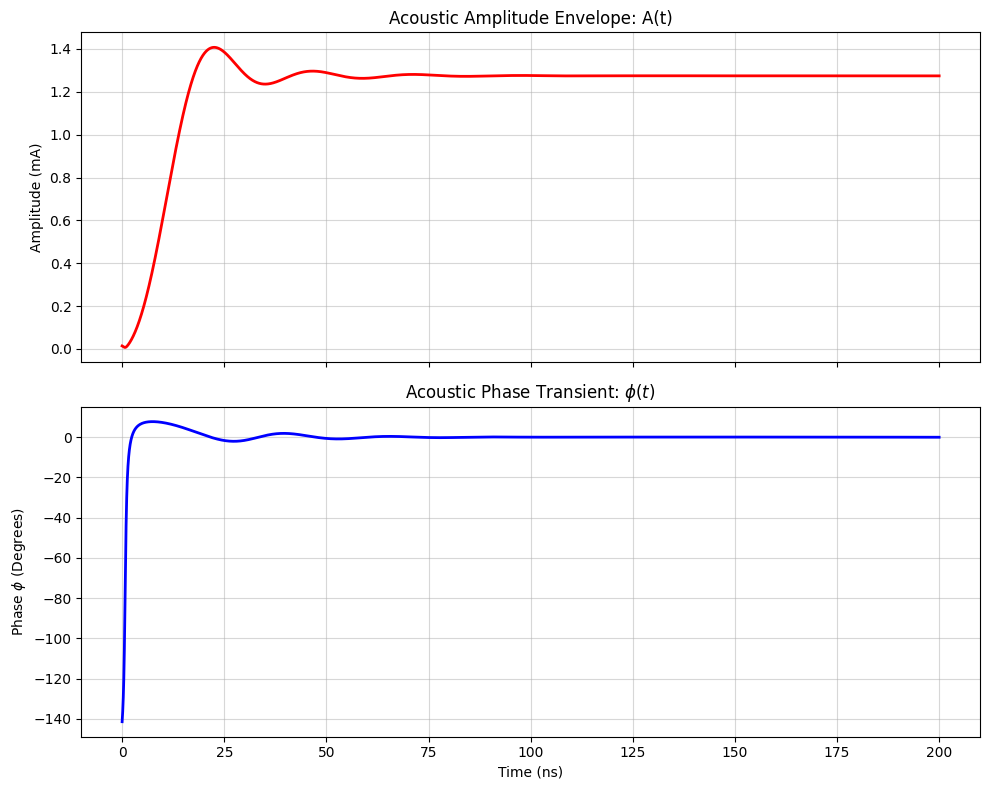

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

def IQ_demodulation(data, t, f=110e6):
    omega = 2 * np.pi * f
    
    # Yes, this automatically calculates the sample rate!
    dt = np.mean(np.diff(t))
    sample_rate = 1.0 / dt

    # Sine-based IQ mixing
    I = data * np.sin(omega * t)
    Q = data * np.cos(omega * t)

    def lowpass(signal, cutoff, fs, order=5):
        nyquist = fs / 2
        b, a = butter(order, cutoff / nyquist, btype='low')
        return filtfilt(b, a, signal)

    # ----------------------------------------------------
    # ADJUSTED CUTOFF FREQUENCY: 50 MHz
    # ----------------------------------------------------
    cutoff = 50e6 
    
    Ilp = lowpass(I, cutoff, sample_rate)
    Qlp = lowpass(Q, cutoff, sample_rate)

    amplitude = 2 * np.sqrt(Ilp**2 + Qlp**2)
    phase = np.unwrap(np.arctan2(Qlp, Ilp))

    return amplitude, phase

# ==========================================
# Execution and Plotting
# ==========================================

# 1. Load the Resampled Uniform SPICE data using Pandas
try:
    df = pd.read_csv('resampled_sim_tran_data.csv')
    # Use the column names defined in the resampling step
    t = df['time_s'].values 
    i_mot = df['I_L_mot_A'].values 
except FileNotFoundError:
    print("Error: 'resampled_sim_tran_data.csv' not found.")
    exit()

# 2. Run your Demodulation Function
amplitude, phase_rad = IQ_demodulation(i_mot, t, f=110e6)

# Convert phase to degrees for easier reading
phase_deg = np.degrees(phase_rad)
phase_deg = phase_deg - phase_deg[-1]

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot Amplitude A(t)
ax1.plot(t * 1e9, amplitude * 1e3, color='red', linewidth=2)
ax1.set_title('Acoustic Amplitude Envelope: A(t)')
ax1.set_ylabel('Amplitude (mA)')
ax1.grid(True, alpha=0.5)

# Plot Phase phi(t)
ax2.plot(t * 1e9, phase_deg, color='blue', linewidth=2)
ax2.set_title('Acoustic Phase Transient: $\phi(t)$')
ax2.set_ylabel('Phase $\phi$ (Degrees)')
ax2.set_xlabel('Time (ns)')
ax2.grid(True, alpha=0.5)


plt.tight_layout()
plt.savefig('iq_demod_results.png')

In [10]:
np.savez("transducer_phase.npz", t = t, phase = phase_deg)